# 09. Многоклассовая классификация: реальные данные «Вино» (178 образцов, 3 сорта)

| | |
|---|---|
| **Уровень** | 2 из 4 — маленькие данные: реальные наборы и базовые приёмы (`2_small`) |
| **Скрипт-источник** | [`09_multiclass_wine.py`](../09_multiclass_wine.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 6 с |

**Цель.** Разобраться с многоклассовым бустингом (softmax) и его вероятностями на маленьком реальном наборе.

### Чему вы научитесь

- K деревьев на итерацию — по одному на класс
- Вероятности через softmax
- log-loss и точность
- Матрица ошибок
- Почему на 178 объектах нужны регуляризация и честное сравнение с логистической регрессией

### Данные

`sklearn.datasets.load_wine` — 178 вин трёх сортов из одного региона Италии, 13 химических показателей (алкоголь, яблочная кислота, флавоноиды, цвет…). Встроен в scikit-learn.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Кросс-валидация: 5 фолдов × 3 повтора
3. **Этап 3.** Устройство softmax-бустинга: K деревьев на итерацию
4. **Этап 4.** Матрица ошибок на отложенных 30%
5. **Этап 5.** Выводы

> Ноутбук собран из `examples/2_small/09_multiclass_wine.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "2_small/09_multiclass_wine.py", title="09. Многоклассовая классификация: «Вино»",
             goal="понять softmax-бустинг и честно сравнить его с линейной моделью")

import lightgbm as lgb
import numpy as np
from sklearn.datasets import load_wine
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

## Этап 1. Данные

In [2]:
data = load_wine(as_frame=True)
X, y = data.data, data.target.to_numpy()
ex.describe(X, y, target="сорт", task="classification", source="sklearn.datasets.load_wine (UCI Wine)")

   Источник: sklearn.datasets.load_wine (UCI Wine)
   Объектов: 178   признаков: 13   память: 0.02 МБ
   Типы признаков: float64 × 13
   Пропусков нет
   Цель «сорт»: класс 0 — 59 (33.1%), класс 1 — 71 (39.9%), класс 2 — 48 (27.0%)
   Первые строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,...,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,[сорт]
0,14.23,1.71,2.43,15.6,127.0,2.80,...,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,...,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,...,2.81,5.68,1.03,3.17,1185.0,0


## Этап 2. Кросс-валидация: 5 фолдов × 3 повтора

   логистическая регрессия    точность 0.9832, log-loss 0.0621


   LightGBM по умолчанию      точность 0.9680, log-loss 0.0757


   LightGBM для малых данных  точность 0.9663, log-loss 0.1325


> ▸ **Вывод.** Логистическая регрессия лучше обеих версий бустинга: сорта почти линейно разделимы по 13 химическим признакам. Наша «настройка для малых данных» оказалась хуже умолчаний по log-loss — интуиция о параметрах часто ошибается, поэтому любую настройку проверяют кросс-валидацией, а не принимают на веру.

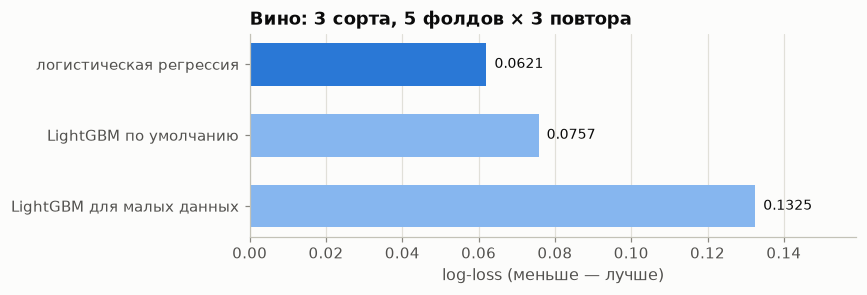

In [3]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0)
models = {
    "логистическая регрессия": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "LightGBM по умолчанию": lgb.LGBMClassifier(verbose=-1, random_state=0),
    "LightGBM для малых данных": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=4,
                                                   min_child_samples=5, verbose=-1, random_state=0),
}
res = {}
for name, m in models.items():
    acc = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    ll = -cross_val_score(m, X, y, cv=cv, scoring="neg_log_loss")
    res[name] = (acc.mean(), ll.mean())
    print(f"   {name:26s} точность {acc.mean():.4f}, log-loss {ll.mean():.4f}")
ex.note("""Логистическая регрессия лучше обеих версий бустинга: сорта почти линейно разделимы по 13 химическим признакам.
Наша «настройка для малых данных» оказалась хуже умолчаний по log-loss — интуиция о параметрах часто ошибается,
поэтому любую настройку проверяют кросс-валидацией, а не принимают на веру.""")
ex.barh({k: v[1] for k, v in res.items()}, best=min(res, key=lambda k: res[k][1]), name="09_models_logloss",
        xlabel="log-loss (меньше — лучше)", title="Вино: 3 сорта, 5 фолдов × 3 повтора", fmt="{:.4f}")
assert res["логистическая регрессия"][1] < min(res["LightGBM по умолчанию"][1], res["LightGBM для малых данных"][1])

## Этап 3. Устройство softmax-бустинга: K деревьев на итерацию

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
m = models["LightGBM для малых данных"].fit(X_tr, y_tr)
info = m.booster_.dump_model()
print(f"   деревьев в модели: {len(info['tree_info'])} = {m.n_estimators} итераций × {m.n_classes_} класса")
raw = m.predict(X_te[:1], raw_score=True)[0]
p = np.exp(raw - raw.max()) / np.exp(raw - raw.max()).sum()
print(f"   сырые оценки первого объекта: {np.round(raw, 3)} → softmax {np.round(p, 3)}; predict_proba {np.round(m.predict_proba(X_te[:1])[0], 3)}")
assert np.allclose(p, m.predict_proba(X_te[:1])[0])

   деревьев в модели: 900 = 300 итераций × 3 класса
   сырые оценки первого объекта: [ 5.021 -6.779 -7.56 ] → softmax [1. 0. 0.]; predict_proba [1. 0. 0.]


## Этап 4. Матрица ошибок на отложенных 30%

In [5]:
cm = confusion_matrix(y_te, m.predict(X_te))
print("   строки — истинный сорт, столбцы — предсказанный")
for i, row in enumerate(cm):
    print(f"   сорт {i}: " + " ".join(f"{v:4d}" for v in row))

   строки — истинный сорт, столбцы — предсказанный
   сорт 0:   18    0    0
   сорт 1:    0   21    0
   сорт 2:    0    0   15


## Этап 5. Выводы

In [6]:
ex.note("""Многоклассовый бустинг строит по дереву на класс; вероятности — softmax сырых оценок.
На маленьких данных легко ошибиться с настройкой: наша «версия для малых данных» проиграла умолчаниям по log-loss.
Любое изменение параметров проверяйте кросс-валидацией, а простую модель держите как ориентир.""")
ex.done()

> ▸ **Вывод.** Многоклассовый бустинг строит по дереву на класс; вероятности — softmax сырых оценок. На маленьких данных легко ошибиться с настройкой: наша «версия для малых данных» проиграла умолчаниям по log-loss. Любое изменение параметров проверяйте кросс-валидацией, а простую модель держите как ориентир.

Готово за 4.5 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Оставьте треть обучающих данных — кто теряет больше: логистическая регрессия или LightGBM?
2. Найдите, какие признаки важнее всего для каждого из трёх сортов (у каждого класса свои деревья).
3. Замените objective на "multiclassova" (один против всех) и сравните log-loss.

## Что дальше

- **Теория в курсе:** [6.3 «Многоклассовая классификация»](../../../lessons/lesson_6_3/README.md).
- **Предыдущий пример:** [08. Функции потерь для регрессии: L2, L1, Хьюбер, квантиль — на данных с выбросами](08_loss_functions_outliers.ipynb)
- **Следующий пример:** [10. Переобучение и ранняя остановка на 300 шумных объектах](10_overfitting_early_stopping.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)